In [1]:
from torchdiffeq import odeint_adjoint as odeint
import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import DataLoader, TensorDataset

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

from src.lyap import LyapunovExponents
from src.networks import NeuralODE1D

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
def build_ic_set(M_total=100):
    # dense center
    M_center = int(M_total * 0.4)
    M_side = (M_total - M_center) // 2

    center = torch.linspace(-0.5, 0.5, M_center)
    left  = torch.linspace(-2.0, -0.5, M_side)
    right = torch.linspace(0.5, 2.0, M_side)

    x_ic = torch.cat([left, center, right])

    # ensure -1,0,1 included
    for v in [-1.0, 0.0, 1.0]:
        idx = (torch.abs(x_ic - v)).argmin()
        x_ic[idx] = v

    return x_ic.unsqueeze(1)  # shape [M,1]

In [5]:
hidden_dim = 50
neural_ode = NeuralODE1D(hidden_dim=hidden_dim).to(device)

x0_grid = build_ic_set(M_total=100).to(device)
x0_grid = x0_grid / 2.0
t = torch.linspace(0., 20., 100)

class trueFunction(nn.Module):
    
    def forward(self, t, y):
        return y - y**3
    
optimizer = torch.optim.Adam(neural_ode.parameters(), lr=1e-3)
# loss_fn = nn.MSELoss()

In [6]:
with torch.no_grad():
    true_y = odeint(trueFunction(), x0_grid, t, method='dopri5')

In [13]:
def get_batch(batch_size=16, batch_time=20):
    # Randomly pick batch_size trajectories
    M = x0_grid.shape[0]
    s = np.random.choice(np.arange(M), batch_size, replace=False)
    batch_y0 = true_y[0, s]

    # Randomly pick starting time for each segment
    max_start = t.shape[0] - batch_time
    t0_idx = np.random.choice(np.arange(max_start), 1)[0]
    batch_t = t[t0_idx:t0_idx+batch_time] - t[t0_idx]

    # Batch trajectory segments
    batch_y = true_y[t0_idx:t0_idx+batch_time, s, :]

    return batch_y0.to(device), batch_t.to(device), batch_y.to(device)

In [14]:
def equilibrium_weights(x_batch, sigma=0.2, w_eq=3.0):
    """
    x_batch: [batch, 1] initial conditions
    sigma: width of Gaussian around equilibrium
    w_eq: max weight multiplier
    """
    eqs = torch.tensor([-1.0, 0.0, 1.0], device=x_batch.device)
    # compute distance from each equilibrium
    dist = x_batch - eqs.view(1, -1)  # shape [batch, 3]
    weights = torch.exp(-0.5 * (dist/sigma)**2)  # Gaussian around each eq
    weights = 1.0 + w_eq * weights.max(dim=1).values  # max weight from closest eq
    return weights  # shape [batch]

In [15]:
for epoch in range(2000):
    optimizer.zero_grad()

    batch_y0, batch_t, batch_y = get_batch()

    pred_traj = odeint(neural_ode, batch_y0, batch_t, method='dopri5', rtol=1e-3, atol=1e-4)

    mse = (pred_traj - batch_y)**2
    mse_per_sample = mse.mean(dim=(0,2))
    
    weights = equilibrium_weights(batch_y0)
    loss = torch.mean(weights * mse_per_sample)
    # loss = loss_fn(pred_traj, batch_y)
    
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")


Epoch 0, Loss = 1.209516
Epoch 50, Loss = 0.888120
Epoch 100, Loss = 1.231770
Epoch 150, Loss = 0.703911
Epoch 200, Loss = 0.212826
Epoch 250, Loss = 0.584975
Epoch 300, Loss = 0.387493
Epoch 350, Loss = 0.234668
Epoch 400, Loss = 3.039408
Epoch 450, Loss = 0.508157
Epoch 500, Loss = 0.248756
Epoch 550, Loss = 0.282997
Epoch 600, Loss = 0.178051
Epoch 650, Loss = 0.266404
Epoch 700, Loss = 0.099324
Epoch 750, Loss = 0.143085
Epoch 800, Loss = 0.197759
Epoch 850, Loss = 1.026125
Epoch 900, Loss = 0.071253
Epoch 950, Loss = 0.611969
Epoch 1000, Loss = 0.042194
Epoch 1050, Loss = 0.196141
Epoch 1100, Loss = 0.272211
Epoch 1150, Loss = 0.172743
Epoch 1200, Loss = 0.158738
Epoch 1250, Loss = 0.834800
Epoch 1300, Loss = 0.507219
Epoch 1350, Loss = 0.190949
Epoch 1400, Loss = 0.109989
Epoch 1450, Loss = 0.179335
Epoch 1500, Loss = 0.184939
Epoch 1550, Loss = 0.134812
Epoch 1600, Loss = 0.192070
Epoch 1650, Loss = 0.387034
Epoch 1700, Loss = 0.232903
Epoch 1750, Loss = 0.183202
Epoch 1800, Los

In [36]:
x0_test = torch.tensor([[0.00006]])
t_test = torch.linspace(0, 10, 200)

with torch.no_grad():
    true_traj = odeint(trueFunction(), x0_test, t_test)
    pred_traj = odeint(neural_ode, x0_test, t_test)

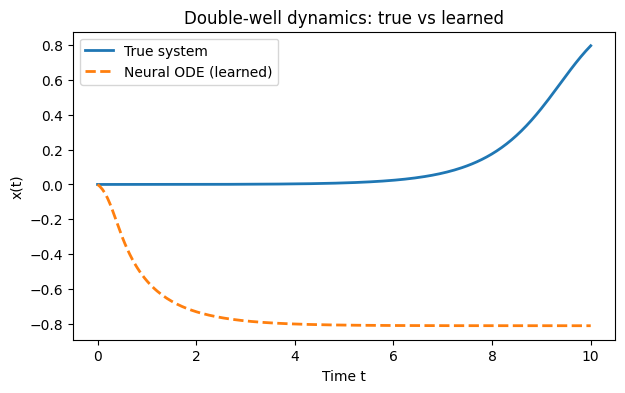

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(t_test, true_traj.squeeze(), label="True system", lw=2)
plt.plot(t_test, pred_traj.squeeze(), '--', label="Neural ODE (learned)", lw=2)
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.legend()
plt.title("Double-well dynamics: true vs learned")
plt.show()

In [18]:
lyap = LyapunovExponents(dim=1, continuous=True, dt=1e-2, integrator='rk4')

x_vals = torch.linspace(-2, 2, 201).unsqueeze(1) # shape [200, 1]
lyap_vals = []

In [19]:
def neural_ode_for_lyap(x):
    return neural_ode(None, x)

In [20]:
for x0 in x_vals:
    ly_exp = lyap.compute(neural_ode_for_lyap, x0, T=10.0)
    lyap_vals.append(ly_exp.item())

lyap_vals = torch.tensor(lyap_vals)

In [21]:
true_func = trueFunction()

def true_jac(x):
    return torch.tensor([[1 - 3*x.item()**2]], dtype=torch.float32)

def f_for_lyap(y):
    return true_func(None, y)

In [22]:
lyap_true = []

for x0 in x_vals:
    ly_exp = lyap.compute(f_for_lyap, torch.tensor([x0]), jac=true_jac, T=10.0)
    lyap_true.append(ly_exp.item())

lyap_true = torch.tensor(lyap_true)

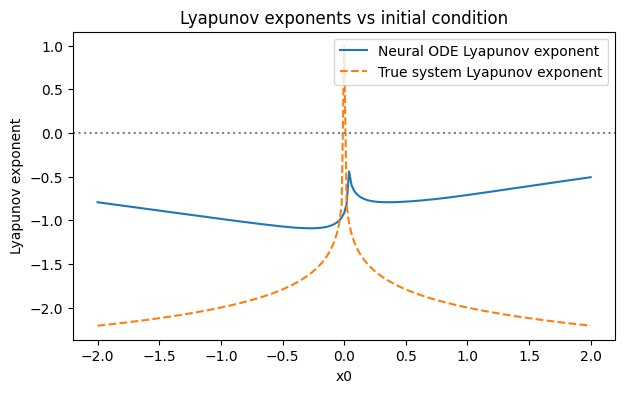

In [23]:
plt.figure(figsize=(7,4))
plt.plot(x_vals.squeeze().numpy(), lyap_vals.numpy(), label="Neural ODE Lyapunov exponent")
plt.plot(x_vals.squeeze().numpy(), lyap_true.numpy(), label="True system Lyapunov exponent", linestyle="--")
plt.axhline(0, color='gray', linestyle=':')
plt.xlabel("x0")
plt.ylabel("Lyapunov exponent")
plt.title("Lyapunov exponents vs initial condition")
plt.legend()
plt.show()